# 01 — Explore `huang_matched_openalex.csv`

**Goal of this notebook:** Understand the structure, coverage, and quality of the ONE file we
reuse from the thesis project, before doing any new data gathering for the conf paper.

Source: `data/matched/huang_matched_openalex.csv`
Contains award-winning papers (Jeff Huang's best-paper dataset, matched to OpenAlex),
2000–2018, plus JCDL and ICWSM appended at the end.

No other thesis data/files are reused. Everything past this notebook is freshly gathered.


## Setup

In [1]:
import pandas as pd
import numpy as np
import ast
from pathlib import Path

pd.set_option('display.max_colwidth', 120)

RAW_PATH = "../../data/matched/huang_matched_openalex.csv"
DATA_DIR = Path('../conf_data')
DATA_DIR.mkdir(exist_ok=True)

df = pd.read_csv(RAW_PATH)
df.shape


(925, 10)

## 1. Basic structure

In [2]:
print(df.columns.tolist())
df.dtypes


['year', 'conference', 'paper_title', 'paper_url', 'authors', 'openalex_id', 'doi', 'oa_title', 'authorships', 'match_route']


year            int64
conference     object
paper_title    object
paper_url      object
authors        object
openalex_id    object
doi            object
oa_title       object
authorships    object
match_route    object
dtype: object

In [3]:
df.head(3)

,year,conference,paper_title,paper_url,authors,openalex_id,doi,oa_title,authorships,match_route
0,2018,AAAI,Memory-Augmented Monte Carlo Tree Search,https://www.semanticscholar.org/paper/2d7fb18fa63f718866055ab494e1b0707b0bd56a,"Chenjun Xiao, University of Alberta ; et al. Jincheng Mei, University of Alberta Martin Müller, University of Alberta",https://openalex.org/W2788603415,10.1609/aaai.v32i1.11531,Memory-Augmented Monte Carlo Tree Search,"[{'author_position': 'first', 'author': {'id': 'https://openalex.org/A5026521600', 'display_name': 'Chenjun Xiao', '...",SS→DOI→OA
1,2018,ACL,Finding syntax in human encephalography with beam search,https://www.semanticscholar.org/paper/8981a71bb7dc6d0e9a25e24fc742e9cd5a511135,"John Hale, Cornell University ; et al. Chris Dyer, DeepMind Adhiguna Kuncoro, University of Oxford Jonathan R. Brenn...",https://openalex.org/W2798397965,10.18653/v1/P18-1254,Finding syntax in human encephalography with beam search,"[{'author_position': 'first', 'author': {'id': 'https://openalex.org/A5054978902', 'display_name': 'John Hale', 'orc...",SS→DOI→OA
2,2018,ACL,Learning to Ask Good Questions: Ranking Clarification Questions using Neural Expected Value of Perfect Information,https://scholar.google.com/scholar?as_q=&num=10&btnG=Search+Scholar&as_epq=Learning+to+Ask+Good+Questions:+Ranking+C...,"Sudha Rao & Hal Daumé III, University of Maryland",https://openalex.org/W2963033005,NaN,Learning to Ask Good Questions: Ranking Clarification Questions using Neural Expected Value of Perfect Information,"[{'author_position': 'first', 'author': {'id': 'https://openalex.org/A5001484153', 'display_name': 'Sudha Rao', 'orc...",GS→title→OA


## 2. Coverage: conferences and years

In [4]:
print("Year range:", df['year'].min(), "-", df['year'].max())
print("\nConferences:")
df['conference'].value_counts()


Year range: 2000 - 2018

Conferences:


conference
CHI           192
ICSE           88
FSE            63
UIST           35
PLDI           32
STOC           31
FOCS           31
IJCAI          27
ACL            26
AAAI           26
SOSP           25
INFOCOM        24
VLDB           21
OSDI           21
KDD            20
CVPR           20
JCDL           20
PODS           20
SIGIR          19
SIGMOD         19
ICML           19
WWW            19
CIKM           16
SIGCOMM        15
SODA           15
NeurIPS        15
ICWSM          15
SIGMETRICS     15
S&P            13
ICCV           12
MOBICOM        11
Name: count, dtype: int64

<Axes: title={'center': 'Award papers per year'}, xlabel='year'>

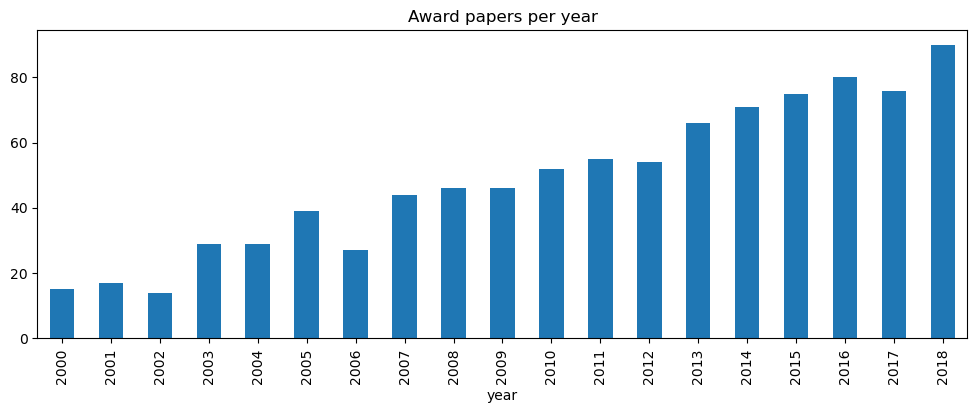

In [5]:
pd.crosstab(df['year'], df['conference']).sum(axis=1).plot(kind='bar', figsize=(12,4), title='Award papers per year')


## 3. Match quality: OpenAlex ID coverage

In [6]:
n_missing = df['openalex_id'].isna().sum()
print(f"Papers missing OpenAlex ID: {n_missing} / {len(df)} ({n_missing/len(df):.1%})")

missing_oa = df[df['openalex_id'].isna()]
missing_oa[['year', 'conference', 'paper_title']]


Papers missing OpenAlex ID: 22 / 925 (2.4%)


,year,conference,paper_title
151,2017,SODA,A (2 + Є) Approximation for Maximum Weight Matching in the Semi-Streaming Model
213,2016,OSDI,Ryoan: A Distributed Sandbox for Untrusted Computation on Secret Data
214,2016,OSDI,Early Detection of Configuration Errors to Reduce Failure Damage
261,2015,CHI,"""I always assumed that I wasn't really that close to [her]"": Reasoning about Invisible Algorithms in News Feeds"
398,2013,CHI,At Home with Agents: Exploring Attitudes Towards Future Smart Energy Infrastructures
416,2013,IJCAI,Bayesian Optimization in High Dimensions via Random Embeddings
451,2012,CHI,Communitysourcing: Engaging Local Crowds to Perform Expert Work Via Physical Kiosks
452,2012,CHI,"Touché: Enhancing Touch Interaction on Humans, Screens, Liquids, and Everyday Objects"
461,2012,CHI,ClayVision: The (Elastic) Image of the City
483,2012,S&P,Don't Trust Satellite Phones: A Security Analysis of Two Satphone Standards


In [7]:
print("Match route breakdown:")
df['match_route'].value_counts(dropna=False)


Match route breakdown:


match_route
SS→DOI→OA      590
SS→title→OA    231
GS→title→OA     69
pre-matched     35
Name: count, dtype: int64

## 4. Authorships field — structure check

In [8]:
sample = df.loc[df['authorships'].notna(), 'authorships'].iloc[0]
parsed = ast.literal_eval(sample)
parsed[0]


{'author_position': 'first',
 'author': {'id': 'https://openalex.org/A5026521600',
  'display_name': 'Chenjun Xiao',
  'orcid': None},
 'institutions': [{'id': 'https://openalex.org/I154425047',
   'display_name': 'University of Alberta',
   'ror': 'https://ror.org/0160cpw27',
   'country_code': 'CA',
   'type': 'education',
   'lineage': ['https://openalex.org/I154425047']}],
 'countries': ['CA'],
 'is_corresponding': True,
 'raw_author_name': 'Chenjun Xiao',
 'raw_affiliation_strings': ['University of Alberta'],
 'affiliations': [{'raw_affiliation_string': 'University of Alberta',
   'institution_ids': ['https://openalex.org/I154425047']}]}

count    869.000000
mean       3.684695
std        2.096081
min        0.000000
25%        2.000000
50%        3.000000
75%        5.000000
max       18.000000
Name: n_authors, dtype: float64


<Axes: title={'center': 'Authors per paper'}, ylabel='Frequency'>

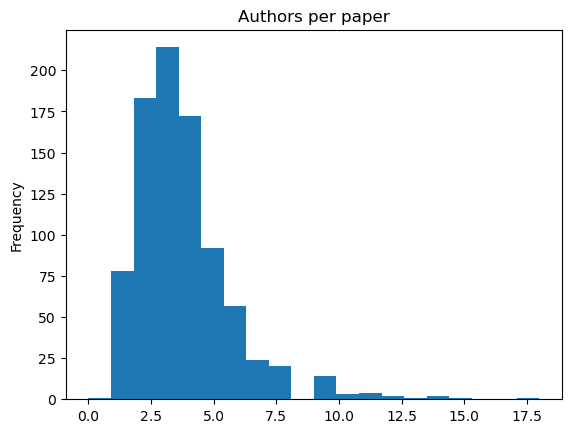

In [9]:
def count_authors(x):
    if pd.isna(x):
        return np.nan
    try:
        return len(ast.literal_eval(x))
    except Exception:
        return np.nan

df['n_authors'] = df['authorships'].apply(count_authors)
print(df['n_authors'].describe())
df['n_authors'].plot(kind='hist', bins=20, title='Authors per paper')


## 5. Missing author OpenAlex IDs within authorships

In [10]:
def missing_author_ids(x):
    if pd.isna(x):
        return np.nan
    try:
        auths = ast.literal_eval(x)
    except Exception:
        return np.nan
    return sum(1 for a in auths if not a.get('author', {}).get('id'))

df['n_missing_author_ids'] = df['authorships'].apply(missing_author_ids)
print("Papers with at least one author missing an OpenAlex author ID:",
      (df['n_missing_author_ids'] > 0).sum())
df[df['n_missing_author_ids'] > 0][['year', 'conference', 'paper_title', 'n_missing_author_ids']]


Papers with at least one author missing an OpenAlex author ID: 14


,year,conference,paper_title,n_missing_author_ids
33,2018,FOCS,Approximating Edit Distance Within Constant Factor in Truly Sub-Quadratic Time,5.0
37,2018,FSE,Do Android Taint Analysis Tools Keep Their Promises?,3.0
39,2018,FSE,Oreo: Detection of Clones in the Twilight Zone,5.0
71,2018,PLDI,"The Semantics of Transactions and Weak Memory in x86, Power, ARM, and C++",3.0
81,2018,STOC,A Constant-Factor Approximation Algorithm for the Asymmetric Traveling Salesman Problem,3.0
116,2017,FOCS,The Matching Problem in General Graphs is in Quasi-NC,2.0
258,2015,CHI,"The Heart Work of Wikipedia: Gendered, Emotional Labor in the World's Largest Online Encyclopedia",2.0
285,2015,INFOCOM,The Power of Slightly More than One Sample in Randomized Load Balancing,1.0
295,2015,S&P,Riposte: An Anonymous Messaging System Handling Millions of Users,3.0
303,2015,SOSP,Coz: Finding Code that Counts with Causal Profiling,2.0


## 6. Duplicate check

In [11]:
dupes = df[df.duplicated(subset=['openalex_id'], keep=False) & df['openalex_id'].notna()]
print(f"Duplicate openalex_id rows: {len(dupes)}")
dupes[['year', 'conference', 'paper_title', 'openalex_id']]


Duplicate openalex_id rows: 0


,year,conference,paper_title,openalex_id


## Summary of exploration

- Total award-winning papers, year range, and conference list confirmed above.
- Unmatched papers (missing `openalex_id`) identified and will be excluded from author-level analysis.
- `authorships` is a stringified list of dicts per paper; each entry has an `author.id` (OpenAlex),
  name, position, and institution info.
- A small number of authors may lack an OpenAlex ID within an otherwise-matched paper — these will
  be dropped at the author level only (paper stays in the dataset).

Next notebook (`02_build_author_paper_table.ipynb`) will:
1. Flatten `authorships` into one row per author-paper pair.
2. Fetch OpenAlex author profiles (career history) for every unique author.
3. Compute career age at award year and label Junior (<=5) / Senior (>=6).


## Export exploration artifacts

In [12]:
missing_oa.to_csv(DATA_DIR / '01_unmatched_papers.csv', index=False)

summary = {
    'total_papers': len(df),
    'year_min': int(df['year'].min()),
    'year_max': int(df['year'].max()),
    'n_conferences': df['conference'].nunique(),
    'n_missing_openalex_id': int(n_missing),
    'n_duplicate_openalex_id_rows': len(dupes),
    'total_author_paper_pairs': int(df['n_authors'].sum()),
    'papers_with_missing_author_ids': int((df['n_missing_author_ids'] > 0).sum()),
}
pd.Series(summary).to_csv(DATA_DIR / '01_exploration_summary.csv')
summary


{'total_papers': 925,
 'year_min': 2000,
 'year_max': 2018,
 'n_conferences': 31,
 'n_missing_openalex_id': 22,
 'n_duplicate_openalex_id_rows': 0,
 'total_author_paper_pairs': 3202,
 'papers_with_missing_author_ids': 14}